In [ ]:
# Load a data file
import os
from ipywidgets import interact
from ipywidgets import widgets, interactive
from IPython.display import display

# import sys
# sys.path.append('/home/geonkim/mixed_states')
# from plotting import *

file_list = os.listdir('./txt/')
dirname  = os.path.basename(os.getcwd())

iter = 66024

Nx1 = 180
Nx2 = Nx1
SUBn = 10
PTOn = 9
STOn = 9
N_L = 2
CAPn = STOn + 3

T0 = str('300K')
e_f = str('WR, {} iters'.format(iter))


file_list = [file for file in file_list if file.startswith(f'NOrderParam_{dirname}{iter:05d}')]
file = file_list[0]
print(file)
txt = './txt/'+ file

NOrderParam_0.4grid_180uc_2L_WR_Ex=5e6+0.000e+00_300K_PTO9STO30_gen_3d_13000.txt


In [2]:
# Load plotting functions

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import scipy.sparse as spm


#from matplotlib_inline.backend_inline import set_matplotlib_formats

# SVG 형식으로 설정
#set_matplotlib_formats('svg')


def D_periodic( N ):
    
    D = np.zeros( ( N, N ))

    for i in range( 0, N ):
        
        if i == 0 :
            
            D[ i ][ 1 ] = 1; D[ i ][ -1 ] = -1
            
        elif i == N - 1:
            
            D[ i ][ 0 ] = 1 ; D[ i ][ -2 ] = -1
            
        else:
            
            D[ i ][ i - 1: i + 2 ] = [ -1, 0 ,1 ]
            
    D = spm.csc_matrix( D )
    
    return D

def D_neuman( N ):
    
    D = np.zeros( ( N, N ) , dtype = np.float32 )

    for i in range( 0, N ):
        
        if i == 0 :
            
            D[ i ] = 0
            
        elif i == N - 1:
            
            D[ i ] = 0
            
        else:
            
            D[ i ][ i - 1: i + 2 ] = [ -1 , 0 ,1 ]
            
    D = spm.csc_matrix( D )

    return D

def kron( a, b , c = None):
    
    if c is None:
        
        return spm.kron( a, b )
    
    else:
        
        d = spm.kron( b, c )
        
        return spm.kron( a, d )
    



def readOrder(path):
    
    dat = np.loadtxt(path)
    
    P1 = dat[:,0] ;P2= dat[:,1] ;P3= dat[:,2]
    P1p1= dat[:,3]; P2p1= dat[:,4]; P3p1= dat[:,5];
    u1p0= dat[:,6]; u2p0= dat[:,7]; u3p0= dat[:,8];
    u1p1= dat[:,9]; u2p1= dat[:,10]; u3p1= dat[:,11]; 
    e11p1= dat[:,12]; e22p1= dat[:,13]; e33p1= dat[:,14]; e12p1= dat[:,15]; e13p1= dat[:,16]; e23p1= dat[:,17];
    E1= dat[:,18]; E2= dat[:,19]; E3= dat[:,20];
    f_bulk= dat[:,21]; f_E1= dat[:,22]; f_E2= dat[:,23]; f_E3= dat[:,24];
    f_gradient= dat[:,25]; f_electric= dat[:,26];f_sum= dat[:,27]
    
    return P1, P2, P3, P1p1, P2p1, P3p1, u1p0, u2p0, u3p0,\
    u1p1, u2p1, u3p1, e11p1, e22p1,e33p1, e12p1, e13p1,e23p1,\
    E1, E2, E3, f_bulk, f_E1, f_E2, f_E3, f_gradient,\
    f_electric, f_sum



def plot_result_pol( A1, A2, A3, X, Y, Z, Nx1, Nx2, Nx3,freeE,\
                 Dx1, Dx2, Dx3 ,dx1, dx2, dx3,le0,file, vxmin, vxmax, vymin, vymax, T0, e_f, step, scale, colorscale):
    
    plt.clf()  # 현재 Figure 초기화
    plt.close('all')  # 모든 Figure 닫기

    Nx_plot = int(Dx1/dx1)
    Ny_plot = int(Dx2/dx2)
    Nz_plot = int(Dx3/dx3)
    
    print( round(Nx_plot * dx1 * le0 * 1e9,3),'nm',  round(Ny_plot* dx1 * le0 * 1e9,3),'nm', round(Nz_plot* dx3 * le0 * 1e9,3),'nm')
    
    A1_plot = A1.reshape(Nx1, Nx2 , Nx3)
    A2_plot = A2.reshape(Nx1, Nx2 , Nx3)
    A3_plot = A3.reshape(Nx1, Nx2 , Nx3)
    
    fig, ax = plt.subplots(2,2, figsize = (20,15))
    
    A1_plot = np.roll( A1_plot, 9, axis = 0 )
    A2_plot = np.roll( A2_plot, 9, axis = 0 )
    A3_plot = np.roll( A3_plot, 9, axis = 0 )

    # Quiver 간격 조정
    step = int(step)
    # X_sparse = X[:,:,Nz_plot].T[::step, ::step]
    # Y_sparse = Y[:,:,Nz_plot].T[::step, ::step]
    # Z_sparse = Z[:,:,Nz_plot].T[::step, ::step]
    # A1_sparse = A1_plot[:,:,Nz_plot].T[::step, ::step]
    # A2_sparse = A2_plot[:,:,Nz_plot].T[::step, ::step]
    # A3_sparse = A3_plot[:,:,Nz_plot].T[::step, ::step]

    
    # Y Z
    c1 = ax[0][0].contourf(Y[Nx_plot,:,:].T[::step, ::step], Z[Nx_plot,:,:].T[::step, ::step],  A1_plot[Nx_plot,:, :].T[::step, ::step], 50, cmap = 'PiYG')
    plt.colorbar(c1,ax=ax[0][0])
    c1.set_clim(-colorscale, colorscale)
    
    ax[0][0].quiver(Y[Nx_plot,:,:].T[::step, ::step], Z[Nx_plot,:,:].T[::step, ::step],  A2_plot[Nx_plot,:, :].T[::step, ::step], A3_plot[Nx_plot,:, :].T[::step, ::step] , scale = scale)
    ax[0][0].tick_params(labelsize = 20)
    ax[0][0].set_xlabel(f'y(nm), x={Dx1}(nm)', size = 20)
    ax[0][0].set_ylabel('z(nm)', size = 20)
    
    # X Z
    c2 = ax[0][1].contourf(X[:,Ny_plot,:].T[::step, ::step], Z[:,Ny_plot,:].T[::step, ::step],  A2_plot[:, Ny_plot,:].T[::step, ::step], 50, cmap = 'PiYG') # Nx2 = int(Nx2/2) plane
    plt.colorbar(c2,ax=ax[0][1])
    c2.set_clim(-colorscale, colorscale)

    c2.set_clim(-0.5, 0.5)
    ax[0][1].quiver(X[:,Ny_plot,:].T[::step, ::step], Z[:,Ny_plot,:].T[::step, ::step],  A1_plot[:,Ny_plot,:].T[::step, ::step], A3_plot[:,Ny_plot,:].T[::step, ::step] , scale = scale)
    ax[0][1].tick_params(labelsize = 20)
    ax[0][1].set_xlim(vxmin,vxmax)
    ax[0][1].set_ylim(vymin,vymax)
    ax[0][1].set_xlabel(f'x (nm), y={Dx2}(nm)', size = 20)
    ax[0][1].set_ylabel('z (nm)', size = 20)
    ax[0][1].set_title(file)
    
    # X Y
    c3 = ax[1][0].contourf( X[:,:,Nz_plot].T[::step, ::step], Y[:,:,Nz_plot].T[::step, ::step],  A3_plot[:,:,Nz_plot].T[::step, ::step], 100, cmap = 'PiYG')  
    plt.colorbar(c3 ,ax=ax[1][0])
    c3.set_clim(-colorscale, colorscale)

    ax[1][0].quiver(X[:,:,Nz_plot].T[::step, ::step], Y[:,:,Nz_plot].T[::step, ::step], A1_plot[:,:,Nz_plot].T[::step, ::step], A2_plot[:,:,Nz_plot].T[::step, ::step], scale = scale )
    ax[1][0].tick_params(labelsize = 20)
    ax[1][0].set_title(f'T0 = {T0}, {e_f}', size=20)
    ax[1][0].set_xlabel('x (nm), z='+str(Dx3)+'(nm)', size = 20)
    ax[1][0].set_ylabel('y (nm)', size = 20)

    # Free energy
    ax[1][1].plot(freeE)
    ax[1][1].set_xlabel('The number of iteration', size = 20)
    ax[1][1].set_ylabel('Free energy', size = 20)
    ax[1][1].tick_params(labelsize = 20)

    plt.tight_layout()  # 레이아웃 최적화

def plot_result_pol_XY( A1, A2, A3, X, Y, Nx1, Nx2, Nx3,\
                Dx3 ,dx3, T0, e_f, step, headwidth, headlength, headaxislength, scale, colorscale):
    
    # Nx_plot = int(Dx1/dx1)
    # Ny_plot = int(Dx2/dx2)
    Nz_plot = int(Dx3/dx3)
    
    # print( round(Nx_plot * dx1 * le0 * 1e9,3),'nm',  round(Ny_plot* dx1 * le0 * 1e9,3),'nm', round(Nz_plot* dx3 * le0 * 1e9,3),'nm')
    
    A1_plot = A1.reshape(Nx1, Nx2 , Nx3)
    A2_plot = A2.reshape(Nx1, Nx2 , Nx3)
    A3_plot = A3.reshape(Nx1, Nx2 , Nx3)
    
    plt.subplots(figsize = (16,12))
    
    A1_plot = np.roll( A1_plot, 9, axis = 0 )
    A2_plot = np.roll( A2_plot, 9, axis = 0 )
    A3_plot = np.roll( A3_plot, 9, axis = 0 )
    
    # Quiver 간격 조정 (예: 2칸씩 건너뛰기)
    step = int(step)
    X_sparse = X[:,:,Nz_plot].T[::step, ::step]
    Y_sparse = Y[:,:,Nz_plot].T[::step, ::step]
    A1_sparse = A1_plot[:,:,Nz_plot].T[::step, ::step]
    A2_sparse = A2_plot[:,:,Nz_plot].T[::step, ::step]
    A3_sparse = A3_plot[:,:,Nz_plot].T[::step, ::step]

    contourf = plt.contourf( X_sparse, Y_sparse, A3_sparse, 100, cmap = 'PiYG')  
    cbar = plt.colorbar(contourf)
    cbar.ax.tick_params(labelsize=20)  # 컬러바 눈금 글꼴 크기
    cbar.set_label('P$_z$ (C/m$^2$)', 
                   size=20,
                   labelpad=30,        # 라벨과 컬러바 사이 간격
                   rotation=0,       # 라벨 회전 (0: 가로, 90: 시계방향 90도, 270: 반시계방향 90도)
                   loc='top')  # 위치 ('top', 'bottom', 'center')
    plt.clim(-colorscale, colorscale)
    plt.clim(-colorscale, colorscale)

    plt.quiver( X_sparse, Y_sparse, A1_sparse, A2_sparse, headwidth=headwidth, headlength=headlength, headaxislength=headaxislength ,scale = scale )
    plt.tick_params(labelsize = 25)
    plt.title(f'T0 = {T0}, {e_f}', size=30)
    plt.xlabel('x (nm), z='+str(Dx3)+'(nm)', size = 30)
    plt.ylabel('y (nm)', size = 30)

def plot_result_pol_XY_multi(A1, A2, A3, X, Y, Nx1, Nx2, Nx3, Dx3_list, dx3, T0, e_f, step, headwidth, headlength, headaxislength, scale, colorscale):
    """
    Dx3_list: z 위치 리스트 (실수 또는 정수, 단위는 dx3)
    """
    import matplotlib.pyplot as plt

    n = len(Dx3_list)
    fig, axs = plt.subplots(1, n, figsize=(8*n, 7))
    if n == 1:
        axs = [axs]
    for idx, Dx3 in enumerate(Dx3_list):
        Nz_plot = int(Dx3/dx3)
        A1_plot = A1.reshape(Nx1, Nx2 , Nx3)
        A2_plot = A2.reshape(Nx1, Nx2 , Nx3)
        A3_plot = A3.reshape(Nx1, Nx2 , Nx3)
        # roll 적용
        A1_plot = np.roll( A1_plot, 9, axis = 0 )
        A2_plot = np.roll( A2_plot, 9, axis = 0 )
        A3_plot = np.roll( A3_plot, 9, axis = 0 )
        step_int = int(step)
        X_sparse = X[:,:,Nz_plot].T[::step_int, ::step_int]
        Y_sparse = Y[:,:,Nz_plot].T[::step_int, ::step_int]
        A1_sparse = A1_plot[:,:,Nz_plot].T[::step_int, ::step_int]
        A2_sparse = A2_plot[:,:,Nz_plot].T[::step_int, ::step_int]
        A3_sparse = A3_plot[:,:,Nz_plot].T[::step_int, ::step_int]
        contourf = axs[idx].contourf(X_sparse, Y_sparse, A3_sparse, 100, cmap='PiYG')
        contourf.set_clim(-colorscale, colorscale)
        cbar = plt.colorbar(contourf, ax=axs[idx])
        cbar.ax.tick_params(labelsize=13)
        cbar.set_label('P$_z$ (C/m$^2$)', size=16, labelpad=20, rotation=270, loc='center')
        axs[idx].set_title(f'z={Dx3:.2f} (nm)', size=22)
        axs[idx].set_xlabel('x (nm)', size=20)
        axs[idx].set_ylabel('y (nm)', size=20)
        axs[idx].tick_params(labelsize=18)
        axs[idx].set_aspect('equal')
        axs[idx].set_xlim(X_sparse.min(), X_sparse.max())
        axs[idx].set_ylim(Y_sparse.min(), Y_sparse.max())
        axs[idx].quiver(X_sparse, Y_sparse, A1_sparse, A2_sparse, headwidth=headwidth, headlength=headlength, headaxislength=headaxislength, scale=scale)
    plt.suptitle(f'T0 = {T0}, {e_f}', size=26)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

def plot_result_pol_XZ( A1, A2, A3, X, Y, Nx1, Nx2, Nx3,\
                  Dx2, dx2, T0, e_f, step, headwidth, headlength, headaxislength, scale, colorscale):
    
    # Nx_plot = int(Dx1/dx1)
    Ny_plot = int(Dx2/dx2)
    # Nz_plot = int(Dx3/dx3)
    
    A1_plot = A1.reshape(Nx1, Nx2 , Nx3)
    A2_plot = A2.reshape(Nx1, Nx2 , Nx3)
    A3_plot = A3.reshape(Nx1, Nx2 , Nx3)
    
    plt.subplots(figsize = (12,18), dpi = 150)
    
    A1_plot = np.roll( A1_plot, 9, axis = 0 )
    A2_plot = np.roll( A2_plot, 9, axis = 0 )
    A3_plot = np.roll( A3_plot, 9, axis = 0 )
    
    # Quiver 간격 조정 (예: 2칸씩 건너뛰기)
    step = int(step)
    X_sparse = X[:, Ny_plot, :].T[::step, ::step]
    Z_sparse = Y[:, Ny_plot, :].T[::step, ::step]
    A1_sparse = A1_plot[:, Ny_plot, :].T[::step, ::step]
    A2_sparse = A2_plot[:, Ny_plot, :].T[::step, ::step]
    A3_sparse = A3_plot[:, Ny_plot, :].T[::step, ::step]

    contourf = plt.contourf( X_sparse, Z_sparse, A2_sparse, 100, cmap = 'PiYG')  
    cbar = plt.colorbar(contourf)
    cbar.ax.tick_params(labelsize=20)  # 컬러바 눈금 글꼴 크기
    cbar.set_label('P$_y$ (C/m$^2$)', 
                   size=20,
                   labelpad=15,        # 라벨과 컬러바 사이 간격
                   rotation=0,       # 라벨 회전 (0: 가로, 90: 시계방향 90도, 270: 반시계방향 90도)
                   loc='top')  # 위치 ('top', 'bottom', 'center')
    plt.clim(-colorscale, colorscale)

    plt.quiver( X_sparse, Z_sparse, A1_sparse, A3_sparse, headwidth=headwidth, headlength=headlength, headaxislength=headaxislength ,scale = scale )
    plt.tick_params(labelsize = 25)
    # plt.title(f'T0 = {T0}, {e_f}', size=30)
    plt.xlabel('x (nm), y='+str(Dx2)+'(nm)', size = 30)
    plt.ylabel('z (nm)', size = 30)
   
    
def plot_result_P_mag( A1, A2, A3, X, Y, Z, Nx1, Nx2, Nx3, freeE,\
                 Dx1, Dx2, Dx3, dx1, dx2, dx3, file, le0, scale):
    
    Nx_plot = int(Dx1/dx1)
    Ny_plot = int(Dx2/dx1)
    Nz_plot = int(Dx3/dx3)
    
    print( round(Nx_plot * dx1 * le0 * 1e9,3),'nm',  round(Ny_plot* dx1 * le0 * 1e9,3),'nm', round(Nz_plot* dx3 * le0 * 1e9,3),'nm')
    
    A1_plot = A1.reshape(Nx1, Nx2 , Nx3)
    A2_plot = A2.reshape(Nx1, Nx2 , Nx3)
    A3_plot = A3.reshape(Nx1, Nx2 , Nx3)
    
    P_mag = (A1_plot[:,Ny_plot,:] * A1_plot[:,Ny_plot,:] + A2_plot[:,Ny_plot,:] * A2_plot[:,Ny_plot,:] + A3_plot[:,Ny_plot,:] * A3_plot[:,Ny_plot,:])**0.5
    
    fig, ax = plt.subplots(2,2, figsize = (27,15))
    
    
    
    c2 = ax[0][1].contourf(X[:,Ny_plot,:].T, Z[:,Ny_plot,:].T,  P_mag.T, 50, cmap = 'PiYG') # Nx2 = int(Nx2/2) plane
    plt.colorbar(c2,ax=ax[0][1])
    ax[0][1].quiver(X[:,Ny_plot,:].T, Z[:,Ny_plot,:].T,  A1_plot[:,Ny_plot,:].T, A3_plot[:,Ny_plot,:].T , scale = scale)
    ax[0][1].tick_params(labelsize = 25)
    #ax[0][1].set_xlim(0,30)
    ax[0][1].set_xlabel('x (nm)', size = 25)
    ax[0][1].set_ylabel('z (nm)', size = 25)
    
    
    
    c1 = ax[0][0].contourf(Y[Nx_plot,:,:].T, Z[Nx_plot,:,:].T,  A1_plot[Nx_plot,:, :].T, 50, cmap = 'PiYG')
    
    plt.colorbar(c1,ax=ax[0][0] )
    c1.set_clim(-0.5, 0.5)
    ax[0][0].quiver(Y[Nx_plot,:,:].T, Z[Nx_plot,:,:].T,  A2_plot[Nx_plot,:, :].T, A3_plot[Nx_plot,:, :].T , scale = scale)
    ax[0][0].tick_params(labelsize = 25)
    ax[0][0].set_xlabel('y(nm)', size = 25)
    ax[0][0].set_ylabel('z(nm)', size = 25)
    
    
    
    
    c3 = ax[1][0].contourf( X[:,:,Nz_plot].T, Y[:,:,Nz_plot].T,  A3_plot[:,:,Nz_plot].T, 100, cmap = 'PiYG')  
    plt.colorbar(c3 ,ax=ax[1][0])
    ax[1][0].quiver( X[:,:,Nz_plot].T, Y[:,:,Nz_plot].T, A1_plot[:,:, Nz_plot].T, A2_plot[:,:,Nz_plot].T )
    ax[1][0].tick_params(labelsize = 25)
    ax[1][0].set_xlabel('x (nm)', size = 25)
    ax[1][0].set_ylabel('y (nm)', size = 25)
    
    
    
    ax[1][1].plot(freeE)
    ax[1][1].set_xlabel('The number of iteration', size = 25)
    ax[1][1].set_ylabel('Free energy', size = 25)
    ax[1][1].tick_params(labelsize = 25)

'''
def plot_result_twoFig_2D( A1, A2, A3, B1, B2, B3, X, Y, Z, Nx1, Nx2, Nx3, freeE,\
                 Dx1, Dx2, Dx3 , scale1, scale2, time,
                vm1, vM1,vm2,vM2, xm, xM, ym, yM, N_roll):
    
    Nx_plot = int(Dx1/dx1)
    Ny_plot = int(Dx2/dx1)
    Nz_plot = int(Dx3/dx3)
    
    curlx_A = kron(Ix, Dy, Iz) @ A3 - kron(Ix, Iy, Dz_neu) @ A2
    curly_A = kron(Ix, Iy, Dz_neu) @ A1 - kron(Dx, Iy, Iz) @ A3
    curlz_A = kron(Dx, Iy, Iz) @ A2 - kron(Ix, Dy, Iz) @ A1
    
    vorticity_A = (curlx_A ** 2 + curly_A ** 2 + curlz_A ** 2)**0.5
    
    curlx_B = kron(Ix, Dy, Iz) @ B3 - kron(Ix, Iy, Dz_neu) @ B2
    curly_B = kron(Ix, Iy, Dz_neu) @ B1 - kron(Dx, Iy, Iz) @ B3
    curlz_B = kron(Dx, Iy, Iz) @ B2 - kron(Ix, Dy, Iz) @ B1
    
    vorticity_B = (curlx_B ** 2 + curly_B ** 2 + curlz_B ** 2)**0.5
    
    print( round(Nx_plot * dx1 * le0 * 1e9,3),'nm',  round(Ny_plot* dx1 * le0 * 1e9,3),'nm', round(Nz_plot* dx3 * le0 * 1e9,3),'nm')
    
    A1_plot = A1.reshape(Nx1, Nx2 , Nx3)
    A2_plot = A2.reshape(Nx1, Nx2 , Nx3)
    A3_plot = A3.reshape(Nx1, Nx2 , Nx3)
    
    B1_plot = B1.reshape(Nx1, Nx2 , Nx3)
    B2_plot = B2.reshape(Nx1, Nx2 , Nx3)
    B3_plot = B3.reshape(Nx1, Nx2 , Nx3)
    
    vorticity_plot_A = vorticity_A.reshape(Nx1, Nx2 , Nx3)
    vorticity_plot_B = vorticity_B.reshape(Nx1, Nx2 , Nx3)
    
    A1_plot = np.roll( A1_plot, N_roll, axis = 0 )
    A2_plot = np.roll( A2_plot, N_roll, axis = 0 )
    A3_plot = np.roll( A3_plot, N_roll, axis = 0 )
    
    B1_plot = np.roll( B1_plot, N_roll, axis = 0 )
    B2_plot = np.roll( B2_plot, N_roll, axis = 0 )
    B3_plot = np.roll( B3_plot, N_roll, axis = 0 )
    
    vorticity_plot_A = np.roll( vorticity_plot_A, N_roll, axis = 0 )
    vorticity_plot_B = np.roll( vorticity_plot_B, N_roll, axis = 0 )

    
    fig, ax = plt.subplots(1,2, figsize = (15,5))

    c1 = ax[0].contourf(X[:,Ny_plot,:].T, Z[:,Ny_plot,:].T, vorticity_plot_A[:,Ny_plot,:].T, 50, cmap = 'PiYG', vmin = vm1, vmax = vM1)
    cb1=plt.colorbar( ScalarMappable(norm=c1.norm, cmap=c1.cmap) , ticks=np.linspace(vm1, vM1, 8), ax=ax[0])
    ax[0].set_title(str(round( time, 3 ) )  +' ps', size = 15)
    ax[0].set_xlim(xm,xM)
    ax[0].set_ylim(ym,yM)
    ax[0].quiver(X[:,Ny_plot,:].T, Z[:,Ny_plot,:].T,  A1_plot[:,Ny_plot,:].T, A3_plot[:,Ny_plot,:].T , scale = scale1)
    ax[0].tick_params(labelsize = 25)
    ax[0].set_xlabel('x (nm)', size = 15)
    ax[0].set_ylabel('z (nm)', size = 15)
    
    c2 = ax[1].contourf(X[:,Ny_plot,:].T, Z[:,Ny_plot,:].T, vorticity_plot_B[:,Ny_plot,:].T, 50, cmap = 'PiYG', vmin = vm2, vmax = vM2)
    cb2=plt.colorbar( ScalarMappable(norm=c2.norm, cmap=c2.cmap) , ticks=np.linspace(vm2,vM2, 8), ax=ax[1])
    ax[1].set_title(str(round( time, 3 ) )  +' ps', size = 15)
    ax[1].set_xlim(xm,xM)
    ax[1].set_ylim(ym,yM)
    ax[1].quiver(X[:,Ny_plot,:].T, Z[:,Ny_plot,:].T,  B1_plot[:,Ny_plot,:].T , B3_plot[:,Ny_plot,:].T  , scale = scale2)
    ax[1].tick_params(labelsize = 25)
    ax[1].set_xlabel('x (nm)', size = 15)
    ax[1].set_ylabel('z (nm)', size = 15)

    fig.tight_layout()
    '''

 
def plot_result_electric( A1, A2, A3, X, Y, Z, Nx1, Nx2, Nx3, freeE,\
                 Dx1, Dx2, Dx3, dx1, dx2, dx3, file, le0, T0, e_f, step, scale):
    
    Nx_plot = int(Dx1/dx1)
    Ny_plot = int(Dx2/dx1)
    Nz_plot = int(Dx3/dx3)
    
    print( round(Nx_plot * dx1 * le0 * 1e9,3),'nm',  round(Ny_plot* dx1 * le0 * 1e9,3),'nm', round(Nz_plot* dx3 * le0 * 1e9,3),'nm')
    
    A1_plot = A1.reshape(Nx1, Nx2 , Nx3)
    A2_plot = A2.reshape(Nx1, Nx2 , Nx3)
    A3_plot = A3.reshape(Nx1, Nx2 , Nx3)
    
    fig, ax = plt.subplots(2,2, figsize = (24,18))
    
    step = int(step)
    # X_sparse = X[:,:,Nz_plot].T[::step, ::step]
    # Y_sparse = Y[:,:,Nz_plot].T[::step, ::step]
    # Z_sparse = Z[:,:,Nz_plot].T[::step, ::step]
    # A1_sparse = A1_plot[:,:,Nz_plot].T[::step, ::step]
    # A2_sparse = A2_plot[:,:,Nz_plot].T[::step, ::step]
    # A3_sparse = A3_plot[:,:,Nz_plot].T[::step, ::step]
    
    c1 = ax[0][0].contourf(Y[Nx_plot,:,:].T[::step, ::step], Z[Nx_plot,:,:].T[::step, ::step],  A1_plot[Nx_plot,:, :].T[::step, ::step], 50, cmap = 'PiYG')
    c1.set_clim(-3e7,3e7)
    plt.colorbar(c1,ax=ax[0][0] )
    ax[0][0].quiver(Y[Nx_plot,:,:].T[::step, ::step], Z[Nx_plot,:,:].T[::step, ::step],  A2_plot[Nx_plot,:, :].T[::step, ::step], A3_plot[Nx_plot,:, :].T[::step, ::step], scale = scale)
    
    
    
    ax[0][0].tick_params(labelsize = 20)
    ax[0][0].set_xlabel(f'y(nm), x={Dx1}(nm)', size = 20)
    ax[0][0].set_ylabel('z(nm)', size = 20)
    
    
    
    ax[0][0].tick_params(labelsize = 20)
    ax[0][0].set_xlabel(f'y(nm), x={Dx1}(nm)', size = 20)
    ax[0][0].set_ylabel('z(nm)', size = 20)
    
    
    c2 = ax[0][1].contourf(X[:,Ny_plot,:].T[::step, ::step], Z[:,Ny_plot,:].T[::step, ::step],  A2_plot[:, Ny_plot,:].T[::step, ::step], 50, cmap = 'PiYG') # Nx2 = int(Nx2/2) plane
    c2.set_clim(-3e7, 3e7)
    plt.colorbar(c2,ax=ax[0][1])
    ax[0][1].quiver(X[:,Ny_plot,:].T[::step, ::step], Z[:,Ny_plot,:].T[::step, ::step],  A1_plot[:,Ny_plot,:].T[::step, ::step], A3_plot[:,Ny_plot,:].T[::step, ::step] , scale = scale)
    
    
    ax[0][1].tick_params(labelsize = 20)
    
    ax[0][1].set_xlabel(f'x (nm), y={Dx2}(nm)', size = 20)
    ax[0][1].set_ylabel('z (nm)', size = 20)
    
    c3 = ax[1][0].contourf( X[:,:,Nz_plot].T[::step, ::step], Y[:,:,Nz_plot].T[::step, ::step],  A3_plot[:,:,Nz_plot].T[::step, ::step], 100, cmap = 'PiYG')  
    plt.colorbar(c3 ,ax=ax[1][0])
    c3.set_clim(-3e7, 3e7)
    ax[1][0].quiver(X[:,:,Nz_plot].T[::step, ::step], Y[:,:,Nz_plot].T[::step, ::step], A1_plot[:,:,Nz_plot].T[::step, ::step], A2_plot[:,:,Nz_plot].T[::step, ::step], scale = scale )
    
    
    
    ax[1][0].tick_params(labelsize = 20)
    ax[1][0].set_xlabel(f'x (nm), z={Dx3}(nm)',  size = 20)
    ax[1][0].set_ylabel('y (nm)', size = 20)
    ax[1][0].set_title(f'T0 = {T0}, {e_f}', size = 20)


    ax[1][1].plot(freeE[:int(iter)])
    ax[1][1].set_xlabel('The number of iteration', size = 20)
    ax[1][1].set_ylabel('Free energy', size = 20)
    ax[1][1].tick_params(labelsize = 20)    
    
def plot_result( A, X, Y, Z, Nx1, Nx2, Nx3, freeE,\
                 Dx1, Dx2, Dx3 , scale):
    
    Nx_plot = int(Dx1/dx1)
    Ny_plot = int(Dx2/dx1)
    Nz_plot = int(Dx3/dx3)
    
    print( round(Nx_plot * dx1 * le0 * 1e9,3),'nm',  round(Ny_plot* dx1 * le0 * 1e9,3),'nm', round(Nz_plot* dx3 * le0 * 1e9,3),'nm')
    
    A_plot = A.reshape(Nx1, Nx2 , Nx3)

    
    fig, ax = plt.subplots(2,2, figsize = (27,15))
    
    c1 = ax[0][0].contourf(Y[Nx_plot,:,:].T, Z[Nx_plot,:,:].T,  A_plot[Nx_plot,:, :].T, 50, cmap = 'PiYG')
    plt.colorbar(c1,ax=ax[0][0])
    ax[0][0].tick_params(labelsize = 25)
    ax[0][0].set_xlabel('y(nm)', size = 25)
    ax[0][0].set_ylabel('z(nm)', size = 25)
    
    
    c2 = ax[0][1].contourf(X[:,Ny_plot,:].T, Z[:,Ny_plot,:].T,  A_plot[:, Ny_plot,:].T, 50, cmap = 'PiYG') # Nx2 = int(Nx2/2) plane
    plt.colorbar(c2,ax=ax[0][1])
    ax[0][1].tick_params(labelsize = 25)
    ax[0][1].set_xlabel('x (nm)', size = 25)
    ax[0][1].set_ylabel('z (nm)', size = 25)
    
    c3 = ax[1][0].contourf( X[:,:,Nz_plot].T, Y[:,:,Nz_plot].T,  A_plot[:,:,Nz_plot].T, 100, cmap = 'PiYG')  
    plt.colorbar(c3 ,ax=ax[1][0])
    ax[1][0].tick_params(labelsize = 25)
    ax[1][0].set_xlabel('x (nm)', size = 25)
    ax[1][0].set_ylabel('y (nm)', size = 25)

    ax[1][1].plot(freeE)
    ax[1][1].set_xlabel('The number of iteration', size = 25)
    ax[1][1].set_ylabel('Free energy', size = 25)
    ax[1][1].tick_params(labelsize = 25)


def plot_result_twoFig_T_2D( A1, A2, A3, B1, B2, B3, X, Y, Z, Nx1, Nx2, Nx3, freeE,\
                 Dx1, Dx2, Dx3 ,dx1, dx2, dx3,Dx,Dy, Dz_neu,Ix, Iy,Iz, le0,file, scale1, scale2, time,
                vm1, vM1,vm2,vM2, xm, xM, ym, yM, N_roll):
    
    Nx_plot = int(Dx1/dx1)
    Ny_plot = int(Dx2/dx1)
    Nz_plot = int(Dx3/dx3)
    
    curlx_A = kron(Ix, Dy, Iz) @ A3 - kron(Ix, Iy, Dz_neu) @ A2
    curly_A = kron(Ix, Iy, Dz_neu) @ A1 - kron(Dx, Iy, Iz) @ A3
    curlz_A = kron(Dx, Iy, Iz) @ A2 - kron(Ix, Dy, Iz) @ A1
    
    #vorticity_A = (curlx_A ** 2 + curly_A ** 2 + curlz_A ** 2)**0.5
    
    curlx_B = kron(Ix, Dy, Iz) @ B3 - kron(Ix, Iy, Dz_neu) @ B2
    curly_B = kron(Ix, Iy, Dz_neu) @ B1 - kron(Dx, Iy, Iz) @ B3
    curlz_B = kron(Dx, Iy, Iz) @ B2 - kron(Ix, Dy, Iz) @ B1
    
    #vorticity_B = (curlx_B ** 2 + curly_B ** 2 + curlz_B ** 2)**0.5
    
    # helicity_A = (curlx_A*A1 + curly_A*A2 + curlz_A*A3)
    vorticity_A = (curlx_A + curly_A + curlz_A)
    vorticity_B = (curlx_B + curly_B + curlz_B)
    
    
    print( round(Nx_plot * dx1 * le0 * 1e9,3),'nm',  round(Ny_plot* dx1 * le0 * 1e9,3),'nm', round(Nz_plot* dx3 * le0 * 1e9,3),'nm')
    
    A1_plot = A1.reshape(Nx1, Nx2 , Nx3)
    A2_plot = A2.reshape(Nx1, Nx2 , Nx3)
    A3_plot = A3.reshape(Nx1, Nx2 , Nx3)
    
    B1_plot = B1.reshape(Nx1, Nx2 , Nx3)
    B2_plot = B2.reshape(Nx1, Nx2 , Nx3)
    B3_plot = B3.reshape(Nx1, Nx2 , Nx3)
    
    
    
    A1_plot_even = A1_plot[::2, ::2, ::2]
    A2_plot_even = A2_plot[::2, ::2, ::2]
    A3_plot_even = A3_plot[::2, ::2, ::2]
    
    B1_plot_even = B1_plot[::2, ::2, ::2]
    B2_plot_even = B2_plot[::2, ::2, ::2]
    B3_plot_even = B3_plot[::2, ::2, ::2]
   
    vorticity_plot_A = vorticity_A.reshape(Nx1, Nx2 , Nx3)
    vorticity_plot_B = vorticity_B.reshape(Nx1, Nx2 , Nx3)


    
    # vorticity_plot_A_even = vorticity_plot_A[::2, :, ::2]
    # vorticity_plot_B_even = vorticity_plot_B[:, :, :]


    # # 결과는 (i_array, j_array, k_array)의 튜플 형태이며, 이를 리스트로 묶으면 다음과 같이 볼 수 있습니다.
    # index_list = list(zip(indices[0], indices[1], indices[2]))
    fig, ax = plt.subplots(figsize=(10, 10), dpi=150)

    c1 = ax.contourf(X[::2, Ny_plot, ::2].T, Z[::2, Ny_plot, ::2].T, vorticity_plot_A[::2, Ny_plot, ::2].T, 100, cmap='coolwarm', vmin = vm1, vmax = vM1) # coolwarm for vorticity, PiYG for helicity

    # ax.set_title(str(round( time, 3 ) )  +' ps', size = 15)

    ax.quiver(X[::2, Ny_plot, ::2].T, Z[::2, Ny_plot, ::2].T,  A1_plot[::2, Ny_plot, ::2].T, A3_plot[::2, Ny_plot, ::2].T , pivot='mid', scale = scale1, width=0.0018, headwidth=4, minshaft=1,minlength=2,headlength=3, headaxislength=2, color='k')
    
    ax.tick_params(labelsize=20)
    plt.xlabel(f'x (nm),  y={Dx2} (nm)', size=20)
    plt.ylabel('z (nm)', size=20)
    ax.set_aspect('equal')


    # ax.set_title(f'Pol_Curl, T0 = {T0}, {e_f}', size=20) 

    fig.tight_layout()

def plot_result_twoFig_T_2D_YZ( A1, A2, A3, B1, B2, B3, X, Y, Z, Nx1, Nx2, Nx3, freeE,\
                 Dx1, Dx2, Dx3 ,dx1, dx2, dx3,Dx,Dy, Dz_neu,Ix, Iy,Iz, le0,file, scale1, scale2, time,
                vm1, vM1,vm2,vM2, xm, xM, ym, yM, N_roll):
    
    Nx_plot = int(Dx1/dx1)
    Ny_plot = int(Dx2/dx1)
    Nz_plot = int(Dx3/dx3)
    
    curlx_A = kron(Ix, Dy, Iz) @ A3 - kron(Ix, Iy, Dz_neu) @ A2
    curly_A = kron(Ix, Iy, Dz_neu) @ A1 - kron(Dx, Iy, Iz) @ A3
    curlz_A = kron(Dx, Iy, Iz) @ A2 - kron(Ix, Dy, Iz) @ A1
    
    #vorticity_A = (curlx_A ** 2 + curly_A ** 2 + curlz_A ** 2)**0.5
    
    curlx_B = kron(Ix, Dy, Iz) @ B3 - kron(Ix, Iy, Dz_neu) @ B2
    curly_B = kron(Ix, Iy, Dz_neu) @ B1 - kron(Dx, Iy, Iz) @ B3
    curlz_B = kron(Dx, Iy, Iz) @ B2 - kron(Ix, Dy, Iz) @ B1
    
    #vorticity_B = (curlx_B ** 2 + curly_B ** 2 + curlz_B ** 2)**0.5
    
    # helicity_A = (curlx_A*A1 + curly_A*A2 + curlz_A*A3)
    vorticity_A = (curlx_A + curly_A + curlz_A)
    vorticity_B = (curlx_B + curly_B + curlz_B)
    
    
    print( round(Nx_plot * dx1 * le0 * 1e9,3),'nm',  round(Ny_plot* dx1 * le0 * 1e9,3),'nm', round(Nz_plot* dx3 * le0 * 1e9,3),'nm')
    
    A1_plot = A1.reshape(Nx1, Nx2 , Nx3)
    A2_plot = A2.reshape(Nx1, Nx2 , Nx3)
    A3_plot = A3.reshape(Nx1, Nx2 , Nx3)
    
    B1_plot = B1.reshape(Nx1, Nx2 , Nx3)
    B2_plot = B2.reshape(Nx1, Nx2 , Nx3)
    B3_plot = B3.reshape(Nx1, Nx2 , Nx3)
    
    
    
    A1_plot_even = A1_plot[::2, ::2, ::2]
    A2_plot_even = A2_plot[::2, ::2, ::2]
    A3_plot_even = A3_plot[::2, ::2, ::2]
    
    B1_plot_even = B1_plot[::2, ::2, ::2]
    B2_plot_even = B2_plot[::2, ::2, ::2]
    B3_plot_even = B3_plot[::2, ::2, ::2]
   
    vorticity_plot_A = vorticity_A.reshape(Nx1, Nx2 , Nx3)
    vorticity_plot_B = vorticity_B.reshape(Nx1, Nx2 , Nx3)


    
    # vorticity_plot_A_even = vorticity_plot_A[:, ::2, ::2]
    # vorticity_plot_B_even = vorticity_plot_B[:, :, :]


    # # 결과는 (i_array, j_array, k_array)의 튜플 형태이며, 이를 리스트로 묶으면 다음과 같이 볼 수 있습니다.
    # index_list = list(zip(indices[0], indices[1], indices[2]))
    fig, ax = plt.subplots(figsize=(10, 10), dpi=150)

    c1 = ax.contourf(Y[Nx_plot, ::2, ::2].T, Z[Nx_plot, ::2, ::2].T, vorticity_plot_A[Nx_plot, ::2, ::2].T, 100, cmap='coolwarm', vmin = vm1, vmax = vM1) # coolwarm for vorticity, PiYG for helicity

    # ax.set_title(str(round( time, 3 ) )  +' ps', size = 15)

    ax.quiver(Y[Nx_plot, ::2, ::2].T, Z[Nx_plot, ::2, ::2].T,  A2_plot[Nx_plot, ::2, ::2].T, A3_plot[Nx_plot, ::2, ::2].T , pivot='mid', scale = scale1, width=0.0018, headwidth=4, minshaft=1,minlength=2,headlength=3, headaxislength=2, color='k')
    
    ax.tick_params(labelsize=20)
    plt.xlabel(f'y (nm),  z={Dx1} (nm)', size=20)
    plt.ylabel('z (nm)', size=20)
    ax.set_aspect('equal')


    # ax.set_title(f'Pol_Curl, T0 = {T0}, {e_f}', size=20) 

    fig.tight_layout()

In [3]:
#Reading data
from matplotlib_inline.backend_inline import set_matplotlib_formats

# SVG 형식으로 설정
set_matplotlib_formats('png')


Nx3 = 84

# Nx3 = SUBn + 1 + (2+PTOn+STOn) * N_L + CAPn

dx1 = 0.4
dx3 = 0.4
le0 = ( 1.73e-10 / (abs(3.8 * ( 298 - 752 ) * 1e5) )) ** 0.5 

t0 = 0.1e-12
dt = 0.5* t0


vxmin = 0 
vxmax = Nx1 * dx1
vymin = 0
vymax = Nx3 * dx3

X, Y, Z = np.meshgrid(np.arange(0, Nx1) * dx1 * le0 * 1e9,\
                      np.arange(0, Nx2) * dx1 * le0 * 1e9,\
                      np.arange(0, Nx3) * dx3 * le0 * 1e9 , indexing='ij')

Dx =  D_periodic(Nx1) / 2 / dx1 / le0
Dy =  D_periodic(Nx2) / 2 / dx1 / le0
Dz_neu = D_neuman(Nx3) / 2 / dx3 / le0


Ix = np.identity(Nx1)
Iy = np.identity(Nx2)
Iz = np.identity(Nx3)


P1p0, P2p0, P3p0, P1, P2, P3, u1p0, u2p0, u3p0,\
u1p1, u2p1, u3p1, e11p1, e22p1,e33p1, e12p1, e13p1,e23p1,\
E1, E2, E3, f_bulk, f_E1, f_E2, f_E3, f_gradient,\
f_electric, f_sum = readOrder(txt)

corresponding_file = txt.replace('NOrderParam', 'NFreeEnergy')
FE_arr = np.loadtxt(corresponding_file)

FE_bulk = FE_arr[:,0]
FE_E1= FE_arr[:,1]
FE_E2= FE_arr[:,2]
FE_E3= FE_arr[:,3]
FE_grad= FE_arr[:,4]
FE_elec= FE_arr[:,5]
FE_sum= FE_arr[:,6]

print('dOnE')


dOnE


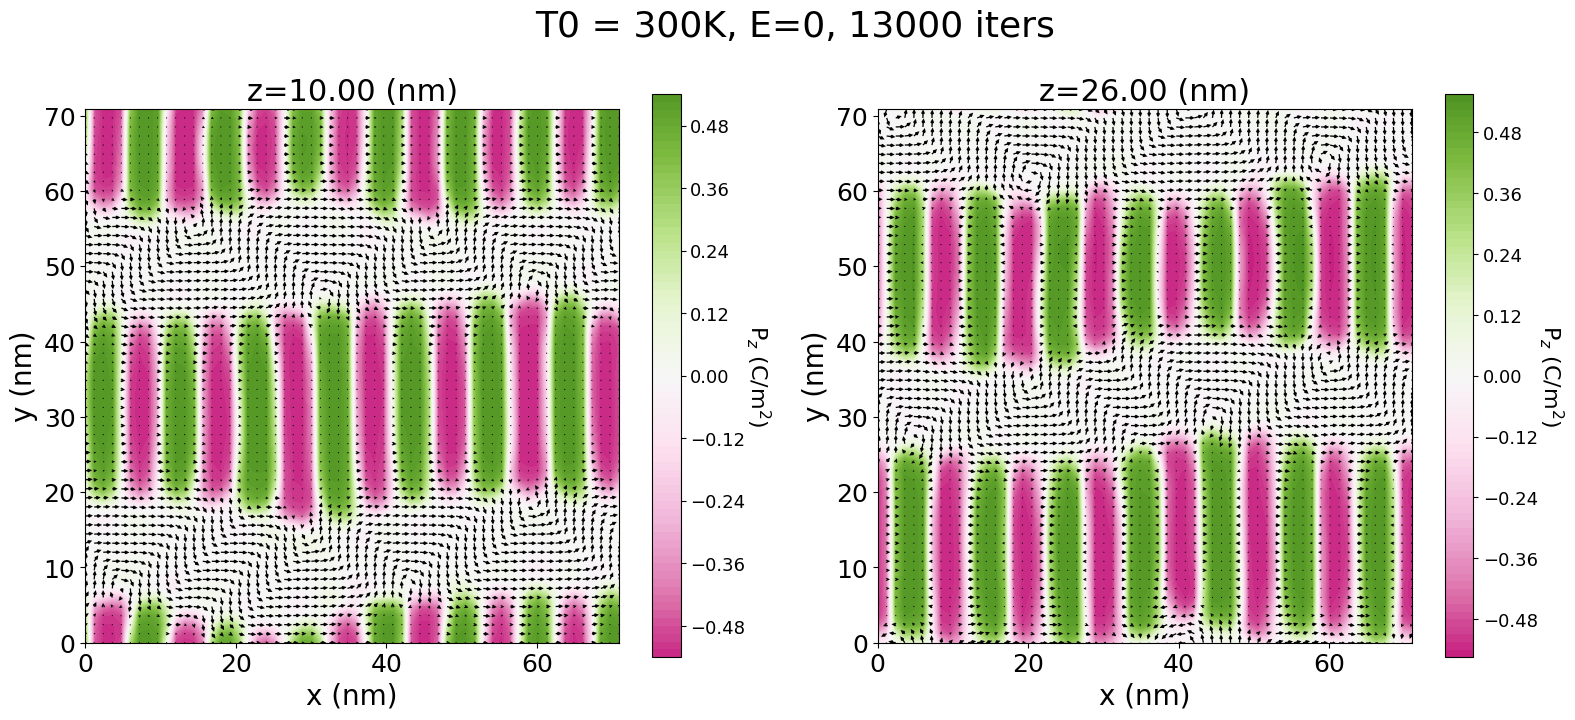

In [4]:
plot_result_pol_XY_multi( P1, P2, P3, X, Y, Nx1, Nx2, Nx3,\
                         [10, 26], dx3, T0, e_f, step=3, headwidth=3, headlength=3, headaxislength=4, scale=30, colorscale=0.7)

In [5]:
# Polarization (with silders)

Dx1_slider = widgets.FloatSlider(value=4, min=0, max=Nx1*dx1, step=0.1, description='Dx1:')
Dx2_slider = widgets.FloatSlider(value=0, min=0, max=Nx2*dx1, step=0.1, description='Dx2:')
Dx3_slider = widgets.FloatSlider(value=10, min=0, max=Nx3*dx3, step=0.1, description='Dx3:')
step_slider = widgets.FloatSlider(value=3, min=1, max=8, step=1, description='step:')
colorscale_slider = widgets.FloatSlider(value=0.7, min=0.01, max=2, step=0.05, description='colorscale:')
scale_slider = widgets.FloatSlider(value=30, min=5, max=75, step=0.05, description='scale:')

interact(plot_result_pol, 
         A1=widgets.fixed(P1), A2=widgets.fixed(P2), A3=widgets.fixed(P3),  
         X=widgets.fixed(X), Y=widgets.fixed(Y), Z=widgets.fixed(Z), 
         Nx1=widgets.fixed(Nx1), Nx2=widgets.fixed(Nx2), Nx3=widgets.fixed(Nx3), 
         freeE=widgets.fixed(FE_sum[:iter]), 
         Dx1=Dx1_slider, Dx2=Dx2_slider, Dx3=Dx3_slider, dx1=widgets.fixed(dx1), dx2=widgets.fixed(dx1), dx3=widgets.fixed(dx3), 
         le0 = widgets.fixed(le0), file=widgets.fixed(file),
         vxmin = widgets.fixed(vxmin), vxmax = widgets.fixed(vxmax), vymin = widgets.fixed(vymin), vymax = widgets.fixed(vymax),
         T0 = widgets.fixed(T0), e_f = widgets.fixed(e_f), step = step_slider, scale = scale_slider, colorscale = colorscale_slider)

interactive(children=(FloatSlider(value=4.0, description='Dx1:', max=72.0), FloatSlider(value=0.0, description…

<function __main__.plot_result_pol(A1, A2, A3, X, Y, Z, Nx1, Nx2, Nx3, freeE, Dx1, Dx2, Dx3, dx1, dx2, dx3, le0, file, vxmin, vxmax, vymin, vymax, T0, e_f, step, scale, colorscale)>

In [6]:
a = int(iter)

/tmp/ipykernel_1311980/204894474.py:7: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('png')


[-5.5323877412651844e-08, 1.2553674677652897e-06, 7.179711053391657e-07, 3.85438430494249e-06, 1.030171136210129e-05, 7.700616328292705e-06, 1.3005717405284779e-05]


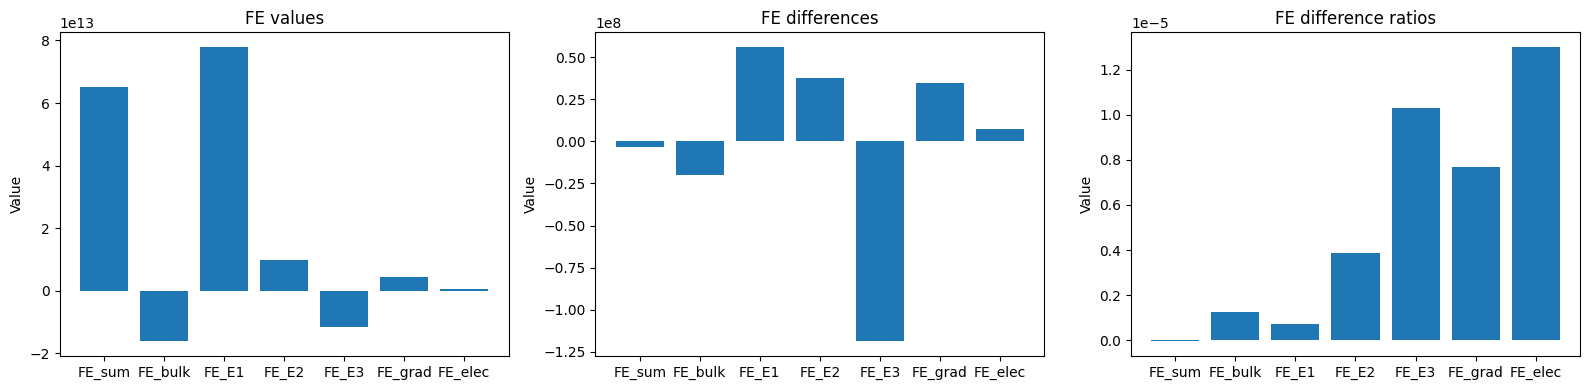

In [7]:
#Free energy 그래프

import matplotlib.pyplot as plt
from IPython.display import set_matplotlib_formats

# SVG 형식으로 설정
set_matplotlib_formats('png')



data1 = [FE_sum[a], FE_bulk[a], FE_E1[a], FE_E2[a], FE_E3[a], FE_grad[a], FE_elec[a]]
data2 = [(FE_sum[a] - FE_sum[a-1]),
         (FE_bulk[a] - FE_bulk[a-1]),
         (FE_E1[a] - FE_E1[a-1]),
         (FE_E2[a] - FE_E2[a-1]),
         (FE_E3[a] - FE_E3[a-1]),
         (FE_grad[a] - FE_grad[a-1]),
         (FE_elec[a] - FE_elec[a-1])]
data3 = [(FE_sum[a] - FE_sum[a-1]) / FE_sum[a],
         (FE_bulk[a] - FE_bulk[a-1]) / FE_bulk[a],
         (FE_E1[a] - FE_E1[a-1]) / FE_E1[a],
         (FE_E2[a] - FE_E2[a-1]) / FE_E2[a],
         (FE_E3[a] - FE_E3[a-1]) / FE_E3[a],
         (FE_grad[a] - FE_grad[a-1]) / FE_grad[a],
         (FE_elec[a] - FE_elec[a-1]) / FE_elec[a]]

print(data3)

# x축 값을 1부터 7까지로 설정
x_values = ('FE_sum', 'FE_bulk', 'FE_E1', 'FE_E2', 'FE_E3', 'FE_grad', 'FE_elec')

# 하나의 figure에 세 개의 subplot 생성
fig, axs = plt.subplots(1, 3, figsize=(16, 4))

# 첫 번째 subplot
axs[0].bar(x_values, data1)
axs[0].set_title('FE values')
#axs[0].set_xlabel('Index')
axs[0].set_ylabel('Value')

# 두 번째 subplot
axs[1].bar(x_values, data2)
axs[1].set_title('FE differences')
#axs[1].set_xlabel('Index')
axs[1].set_ylabel('Value')

# 세 번째 subplot
axs[2].bar(x_values, data3)
axs[2].set_title('FE difference ratios')
#axs[2].set_xlabel('Index')
axs[2].set_ylabel('Value')

# 레이아웃 조정
plt.tight_layout()

# 그래프 보여주기
plt.show()


In [19]:
E1_sliced = E1.reshape(Nx1, Nx2, Nx3)[:,:,31:61]
E2_sliced = E2.reshape(Nx1, Nx2, Nx3)[:,:,31:61]
E3_sliced = E3.reshape(Nx1, Nx2, Nx3)[:,:,31:61]

In [20]:
def plot_result_electric( A1, A2, A3, X, Y, Z, Nx1, Nx2, Nx3, freeE,\
                 Dx1, Dx2, Dx3, dx1, dx2, dx3, file, le0, T0, e_f, step, scale, colorscale):
    
    Nx_plot = int(Dx1/dx1)
    Ny_plot = int(Dx2/dx1)
    Nz_plot = int(Dx3/dx3)
    
    print( round(Nx_plot * dx1 * le0 * 1e9,3),'nm',  round(Ny_plot* dx1 * le0 * 1e9,3),'nm', round(Nz_plot* dx3 * le0 * 1e9,3),'nm')
    
    A1_plot = A1.reshape(Nx1, Nx2 , Nx3)
    A2_plot = A2.reshape(Nx1, Nx2 , Nx3)
    A3_plot = A3.reshape(Nx1, Nx2 , Nx3)
    
    fig, ax = plt.subplots(2,2, figsize = (24,18))
    
    step = int(step)
    # X_sparse = X[:,:,Nz_plot].T[::step, ::step]
    # Y_sparse = Y[:,:,Nz_plot].T[::step, ::step]
    # Z_sparse = Z[:,:,Nz_plot].T[::step, ::step]
    # A1_sparse = A1_plot[:,:,Nz_plot].T[::step, ::step]
    # A2_sparse = A2_plot[:,:,Nz_plot].T[::step, ::step]
    # A3_sparse = A3_plot[:,:,Nz_plot].T[::step, ::step]
    
    c1 = ax[0][0].contourf(Y[Nx_plot,:,:].T[::step, ::step], Z[Nx_plot,:,:].T[::step, ::step],  A1_plot[Nx_plot,:, :].T[::step, ::step], 50, cmap = 'PiYG')
    c1.set_clim(-colorscale, colorscale)
    plt.colorbar(c1,ax=ax[0][0] )
    ax[0][0].quiver(Y[Nx_plot,:,:].T[::step, ::step], Z[Nx_plot,:,:].T[::step, ::step],  A2_plot[Nx_plot,:, :].T[::step, ::step], A3_plot[Nx_plot,:, :].T[::step, ::step], scale = scale)
    
    
    
    ax[0][0].tick_params(labelsize = 20)
    ax[0][0].set_xlabel(f'y(nm), x={Dx1}(nm)', size = 20)
    ax[0][0].set_ylabel('z(nm)', size = 20)
    # ax[0][0].set_ylim(13, 24)
    
    
    
    ax[0][0].tick_params(labelsize = 20)
    ax[0][0].set_xlabel(f'y(nm), x={Dx1}(nm)', size = 20)
    ax[0][0].set_ylabel('z(nm)', size = 20)
    
    
    c2 = ax[0][1].contourf(X[:,Ny_plot,:].T[::step, ::step], Z[:,Ny_plot,:].T[::step, ::step],  A2_plot[:, Ny_plot,:].T[::step, ::step], 50, cmap = 'PiYG') # Nx2 = int(Nx2/2) plane
    c2.set_clim(-colorscale, colorscale)
    plt.colorbar(c2,ax=ax[0][1])
    ax[0][1].quiver(X[:,Ny_plot,:].T[::step, ::step], Z[:,Ny_plot,:].T[::step, ::step],  A1_plot[:,Ny_plot,:].T[::step, ::step], A3_plot[:,Ny_plot,:].T[::step, ::step] , scale = scale)
    
    
    ax[0][1].tick_params(labelsize = 20)
    
    ax[0][1].set_xlabel(f'x (nm), y={Dx2}(nm)', size = 20)
    ax[0][1].set_ylabel('z (nm)', size = 20)
    
    c3 = ax[1][0].contourf( X[:,:,Nz_plot].T[::step, ::step], Y[:,:,Nz_plot].T[::step, ::step],  A3_plot[:,:,Nz_plot].T[::step, ::step], 100, cmap = 'PiYG')  
    plt.colorbar(c3 ,ax=ax[1][0])
    c3.set_clim(-colorscale, colorscale)
    ax[1][0].quiver(X[:,:,Nz_plot].T[::step, ::step], Y[:,:,Nz_plot].T[::step, ::step], A1_plot[:,:,Nz_plot].T[::step, ::step], A2_plot[:,:,Nz_plot].T[::step, ::step], scale = scale )
    
    
    
    ax[1][0].tick_params(labelsize = 20)
    ax[1][0].set_xlabel(f'x (nm), z={Dx3}(nm)',  size = 20)
    ax[1][0].set_ylabel('y (nm)', size = 20)
    ax[1][0].set_title(f'T0 = {T0}, {e_f}', size = 20)


    ax[1][1].plot(freeE[:int(iter)])
    ax[1][1].set_xlabel('The number of iteration', size = 20)
    ax[1][1].set_ylabel('Free energy', size = 20)
    ax[1][1].tick_params(labelsize = 20)    

4.006 nm 0.0 nm 6.008 nm


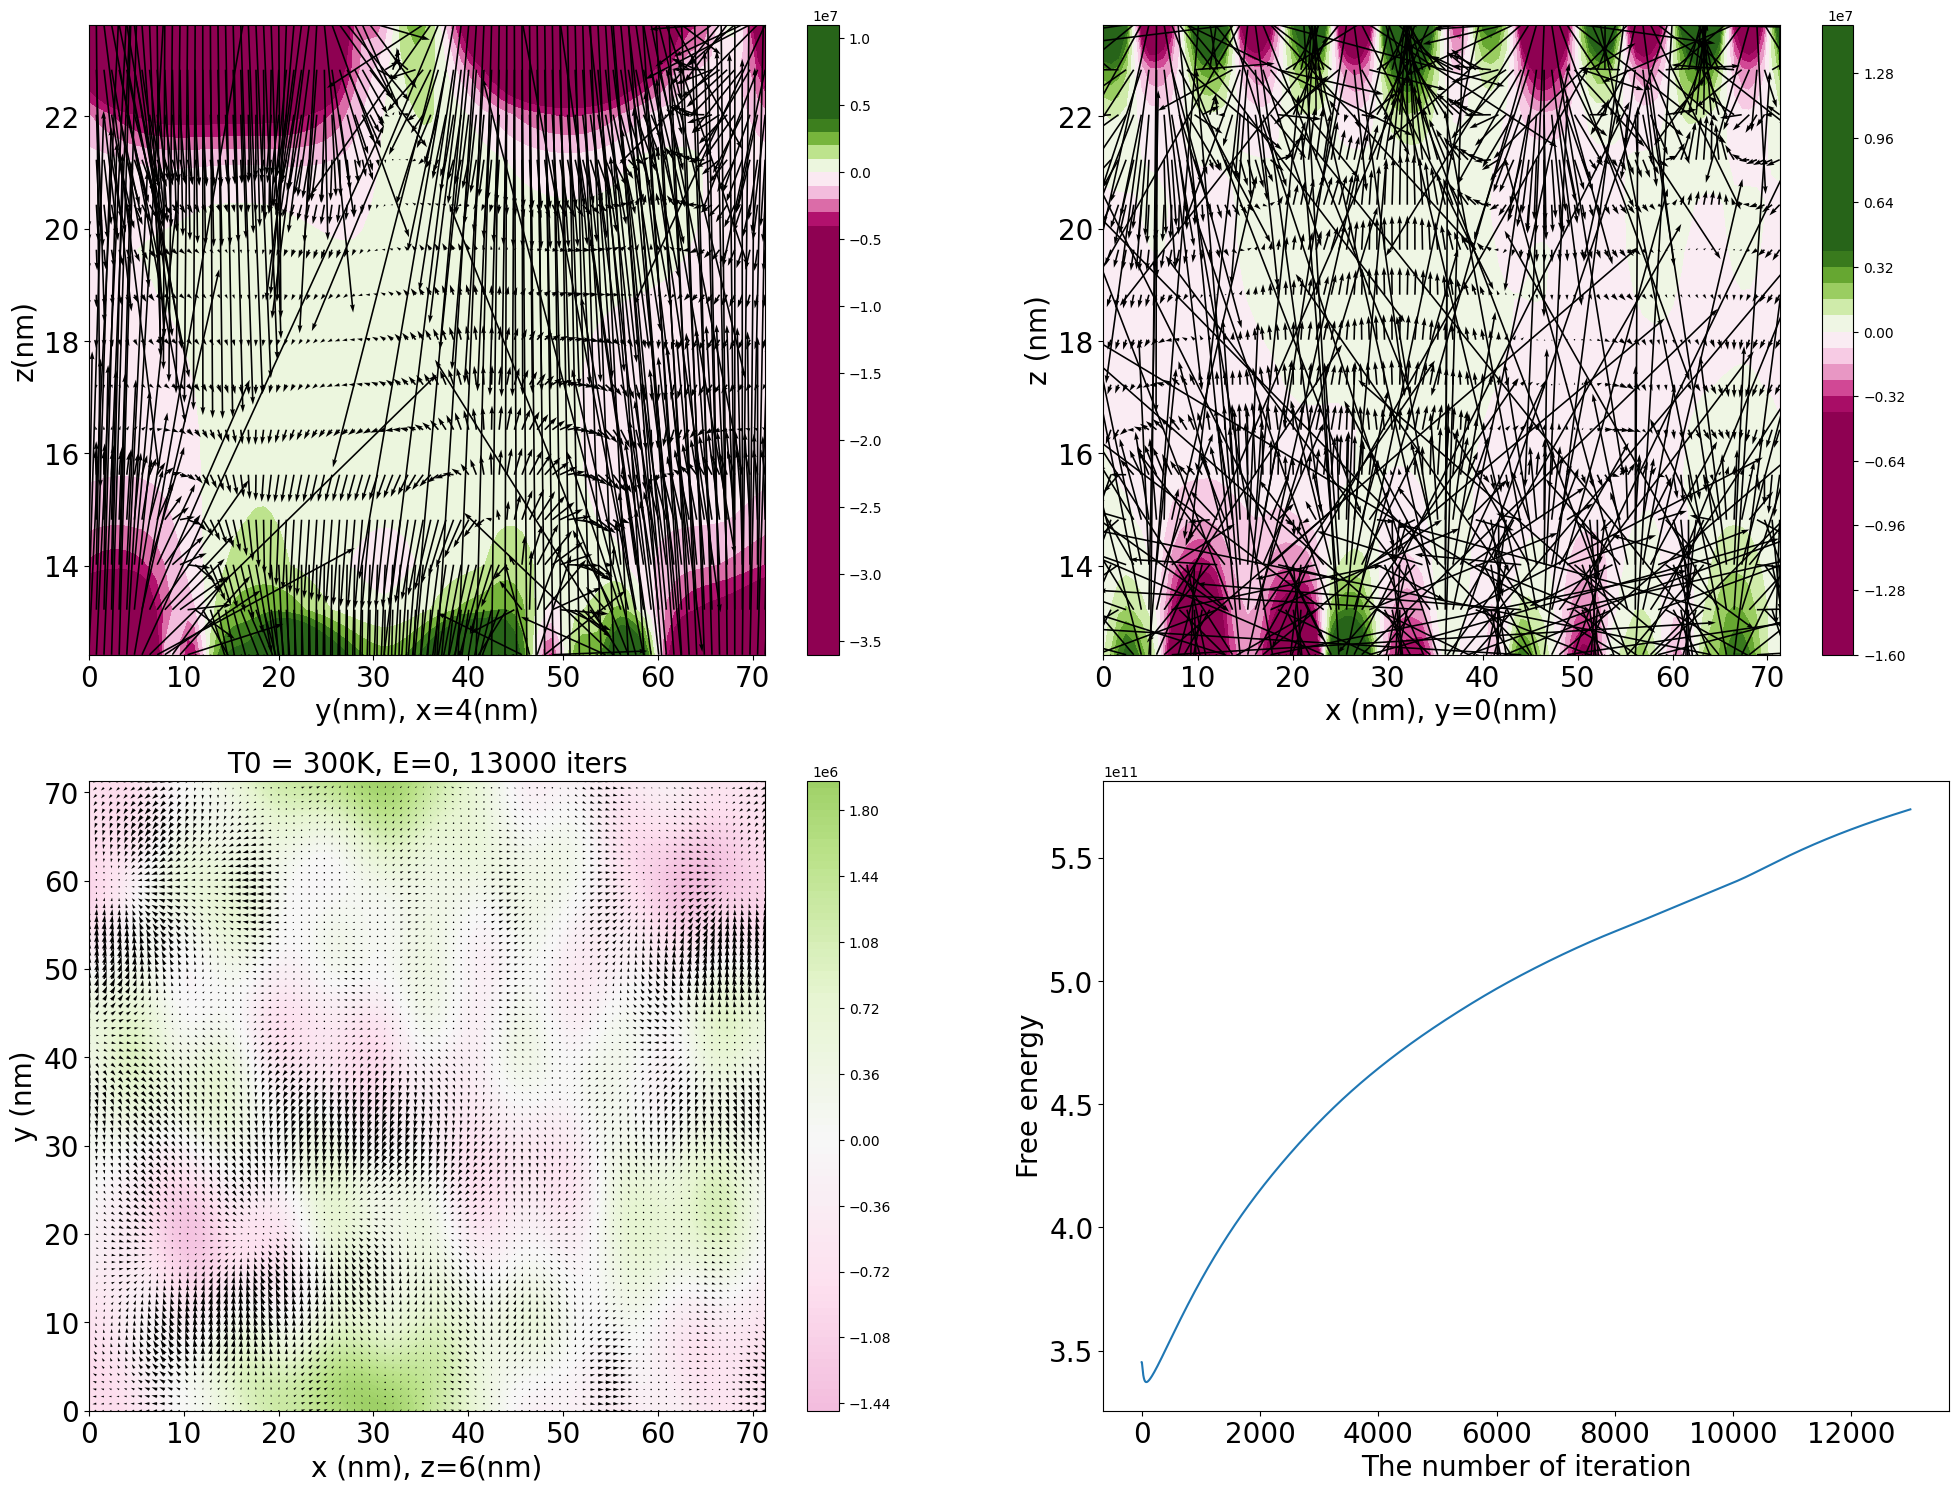

In [22]:
# 직접 값 입력
Dx1_val = 4
Dx2_val = 0
Dx3_val = 6
step_val = 2
scale_val = 5e7
colorscale_val = 4e6

# 함수 직접 호출
plot_result_electric(
    A1=E1_sliced.reshape(Nx1*Nx2*30), A2=E2_sliced.reshape(Nx1*Nx2*30), A3=E3_sliced.reshape(Nx1*Nx2*30),
    X=X[:,:,31:61], Y=Y[:,:,31:61], Z=Z[:,:,31:61],
    Nx1=Nx1, Nx2=Nx2, Nx3=30,
    freeE=FE_elec[:iter],
    Dx1=Dx1_val, Dx2=Dx2_val, Dx3=Dx3_val,
    dx1=dx1, dx2=dx1, dx3=dx3,
    file=file, le0=le0,
    T0=T0, e_f=e_f,
    step=step_val, scale=scale_val, colorscale=colorscale_val
)